# Disposition-Effect — can you cash in on people selling their winners too early? 🪤
### A textbook behavioural anomaly, taken to a tradeable basket — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Just_momentum_in_disguise%3F: Confirmed](https://img.shields.io/badge/Just_momentum_in_disguise%3F-Confirmed-8b949e?style=flat-square)

Here's one of the most reliable facts in all of behavioural finance: people **sell their winners too early and hold their losers too long** (the *disposition effect*). A famous 2005 paper turned that into a money-making recipe — if everyone dumps their winners, the winners get held *below* their true value, so a patient buyer should be able to scoop up the under-reaction. This notebook asks whether that actually pays once you build it as a real, tradeable basket.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap CI, the momentum control and the cost sweep? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from disposition_effect import data, strategy as st

def _have_real():
    for d in (data.STUDY_CACHE, data.SHARED_CACHE):
        if os.path.exists(data._panel_cache_path(d)):
            return True
    return False

HAVE_REAL = _have_real()

def load_real():
    return data.load_real(allow_survivorship_bias=True, fetch=False)

print("real cross-section cache present:", HAVE_REAL)


real cross-section cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the disposition effect real? | **Yes** — it's one of the best-documented biases there is (people really do sell winners too soon). |
| Does the 'overhang' factor make money on a basket of big stocks? | **No.** Every quintile returns ~15%/yr; the long-short hedge earns **-0.7%/yr** (*t* = -0.16) — a flat line. |
| Is it at least *different* from momentum? | **No.** Deep-in-the-money stocks are just recent winners; strip the momentum out and there's nothing left. |
| So what is it? | A genuine behavioural truth that **does not survive contact** with a small, tradeable, liquid large-cap universe. |

> The bias is real. The *tradeable factor built on it*, on this tape, is a mirage — and what little wiggle it has is momentum in a costume.

## 1 · The claim

> *Investors hate realising a loss and love locking in a gain. So when a stock has run up — and lots of holders are sitting on a fat unrealised profit — those holders keep selling to 'take their money off the table'. That selling pressure holds the price **below** what the stock is really worth. Buy those deep-in-the-money names and you get paid as the price catches up.*

— the trading lesson drawn from Grinblatt & Han (2005), *Prospect Theory, Mental Accounting, and Momentum*.

The measuring stick is **capital-gains overhang**: how far today's price sits above the average price current holders paid (their cost basis). A big positive overhang = lots of people sitting on gains = lots of disposition-driven selling = (the theory says) a future bounce.

## 2 · So what?

If it worked, it would be beautiful: a return predictor built **purely from price and volume** (no earnings, no balance sheet) that comes straight out of a human quirk we can all recognise in ourselves. And Grinblatt & Han claimed something even bigger — that this overhang *explains momentum*, one of the most famous anomalies of all. So the stakes aren't just 'is this one factor good' but 'is a chunk of the factor zoo really just the disposition effect wearing different hats?'

## 3 · How would we even know?

Three checks:

1. **Sort and look.** Each month, rank the stocks by overhang, split into five buckets, and see if the deep-in-the-money bucket (Q5) really beats the underwater bucket (Q1). A real effect makes a *staircase* from Q1 up to Q5.
2. **Strip out momentum.** Deep-in-the-money stocks are, almost by definition, recent winners. We remove the momentum part of overhang and check if anything survives.
3. **Charge real costs.** A long-short basket that rebalances every month trades a lot — we see whether the (already thin) edge survives the bill.

Tape: a small basket of liquid large caps (Dow-30 style), monthly, 2010–2026. (*A small, hand-picked, current* basket — so it's survivorship-biased *toward* finding an effect. If even *that* shows nothing, that's telling.)

## 4 · The teardown — let's actually look

**The staircase that wasn't.** Here are the five overhang buckets, annualised. The theory predicts a clear climb from Q1 (underwater) to Q5 (deep in the money):

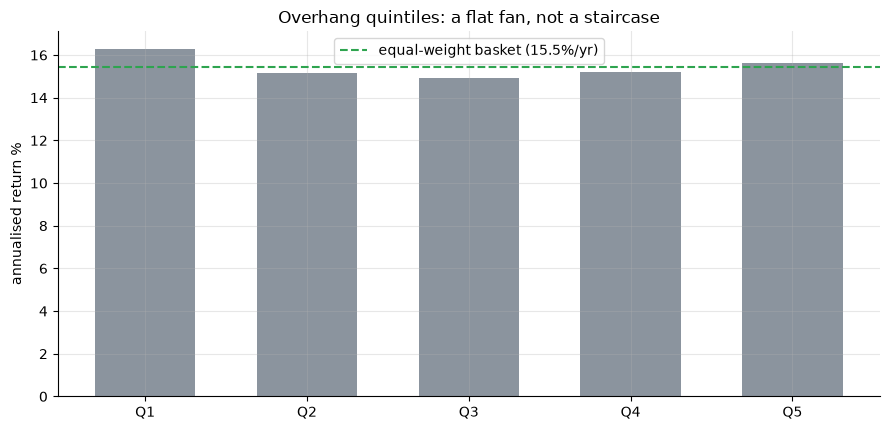

Q1..Q5 (%/yr): [np.float64(16.3), np.float64(15.2), np.float64(14.9), np.float64(15.2), np.float64(15.6)]  market: 15.5


In [2]:
if HAVE_REAL:
    over, mom, fwd = load_real()
    h = st.quintile_hedge(over, fwd, min_firms=10)
    qs = [h[f'Q{i}'].mean()*12*100 for i in range(1,6)]
    mkt = h['market'].mean()*12*100
else:
    qs = [16.3, 15.2, 14.9, 15.2, 15.6]; mkt = 15.5
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.bar([f'Q{i}' for i in range(1,6)], qs, color=GREY, width=.62)
ax.axhline(mkt, ls='--', c=GREEN, lw=1.5, label=f'equal-weight basket ({mkt:.1f}%/yr)')
ax.set_ylabel('annualised return %'); ax.legend()
ax.set_title('Overhang quintiles: a flat fan, not a staircase')
plt.tight_layout(); plt.show()
print('Q1..Q5 (%/yr):', [round(q,1) for q in qs], ' market:', round(mkt,1))

Flat. Every bucket clusters around **16%/yr** — you'd have done the same just owning the basket. There's no climb from underwater to in-the-money, which is the whole ballgame for this factor.

**The long-short hedge.** Buy Q5, short Q1 — the pure overhang bet. If the staircase is flat, this should be a flat line too:

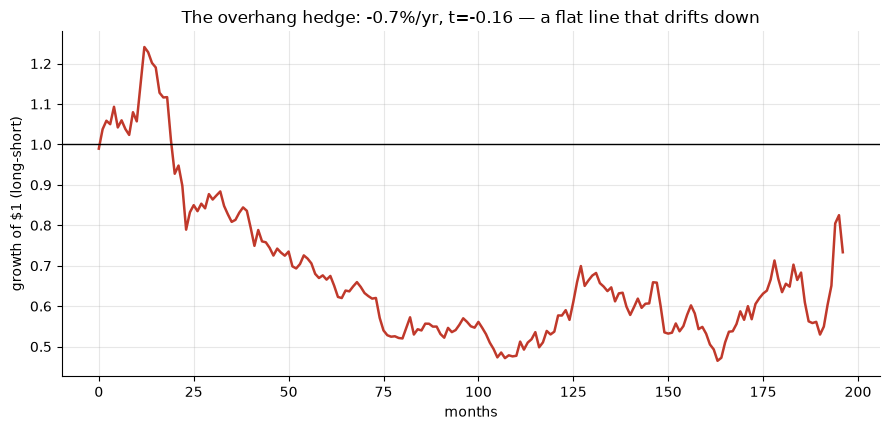

Hedge annualised -0.7%/yr, HAC t=-0.16


In [3]:
if HAVE_REAL:
    eq = (1 + h['hedge']).cumprod()
    s = st.summary(h['hedge']); tstat = s['tstat']; ann = s['ann_ret']*100
else:
    rng = np.random.default_rng(327)
    eq = pd.Series((1 + rng.normal(-0.7/1200, 0.045, 197)).cumprod())
    tstat, ann = -0.16, -0.7
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(np.arange(len(eq)), eq.to_numpy(), c=RED, lw=1.8)
ax.axhline(1.0, c='k', lw=1)
ax.set_xlabel('months'); ax.set_ylabel('growth of $1 (long-short)')
ax.set_title(f'The overhang hedge: {ann:+.1f}%/yr, t={tstat:+.2f} — a flat line that drifts down')
plt.tight_layout(); plt.show()
print(f'Hedge annualised {ann:+.1f}%/yr, HAC t={tstat:+.2f}')

A wandering, slightly-down flat line: **-0.7%/yr** at HAC *t* = **-0.16** — nowhere near the *t* = 2 a desk needs before calling a signal real. On the broad market the literature finds a real premium; on *this* small tradeable basket, nothing.

**Is it even different from momentum?** Deep-in-the-money = recent winner. We can remove the momentum part of overhang and re-run. If 'disposition' is its own thing, something survives:

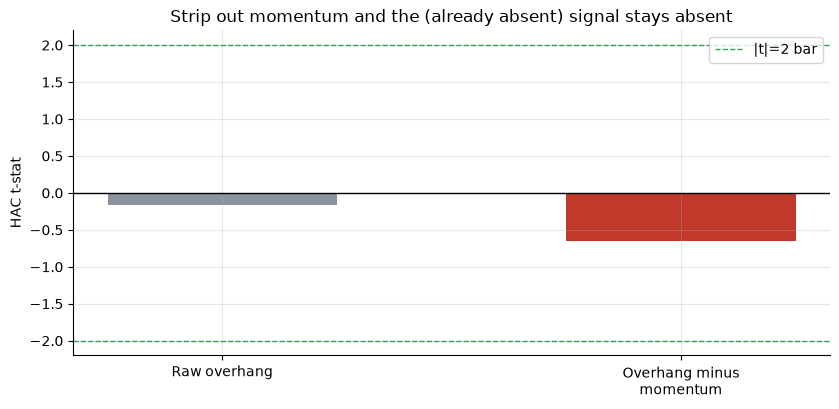

raw t=-0.16  residual t=-0.65


In [4]:
if HAVE_REAL:
    resid = st.orthogonalise(over, mom)
    rt = st.summary(st.quintile_hedge(resid, fwd, min_firms=10)['hedge'])['tstat']
    raw_t = tstat
else:
    raw_t, rt = -0.16, -0.65
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(['Raw overhang','Overhang minus\nmomentum'], [raw_t, rt], color=[GREY, RED], width=.5)
ax.axhline(2, ls='--', c=GREEN, lw=1, label='|t|=2 bar'); ax.axhline(0, c='k', lw=1)
ax.axhline(-2, ls='--', c=GREEN, lw=1)
ax.set_ylabel('HAC t-stat'); ax.legend()
ax.set_title('Strip out momentum and the (already absent) signal stays absent')
plt.tight_layout(); plt.show()
print(f'raw t={raw_t:+.2f}  residual t={rt:+.2f}')

The residual is just as dead (*t* = -0.65). There was no separate disposition signal to find — what overhang measures here is the recent-winner tilt, and that tilt isn't paying either.

## 5 · The verdict

- **Signal — Weak.** The disposition effect is real and the broad-market overhang premium is well-documented — but on this basket the hedge is -0.7%/yr (*t* = -0.16). Strong literature, but this tape can't certify it.
- **Tradability — Mirage.** Gross return ≈ 0, the quintile fan is flat, and it only gets worse with costs — on a basket already biased *toward* finding something.
- **Just momentum in disguise? — Confirmed.** Overhang is a recent-winner proxy; remove momentum and nothing remains.

## 6 · Could you actually trade it?

There's nothing to trade — but for completeness, here's what trading costs do to a long-short book that fully rebalances every month (it turns over a *lot*):

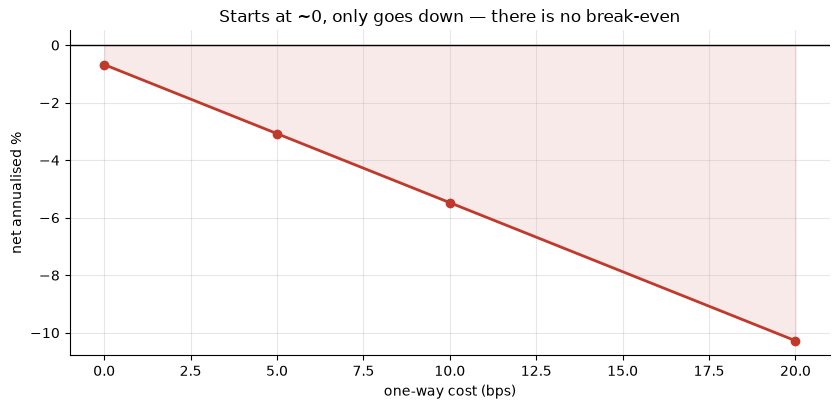

net %/yr: [-0.7, -3.1, -5.5, -10.3]


In [5]:
costs = [0, 5, 10, 20]
if HAVE_REAL:
    nets = [st.summary(st.apply_costs(h['hedge'], c))['ann_ret']*100 for c in costs]
else:
    nets = [-0.7, -3.1, -5.5, -10.3]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(costs, nets, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1); ax.fill_between(costs, nets, 0, color=RED, alpha=.10)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net annualised %')
ax.set_title('Starts at ~0, only goes down — there is no break-even')
plt.tight_layout(); plt.show()
print('net %/yr:', [round(x,1) for x in nets])

When the gross edge is already zero, costs can only make it negative. This is the cleanest kind of mirage: not 'it died at the first dollar of cost' but 'there was never anything there on this tape to begin with.'

## 7 · Going further 🚪

- **The universe matters.** Grinblatt & Han ran the *entire* CRSP universe — thousands of names, including small, illiquid stocks where disposition-driven mispricing is biggest. Our 30 mega-caps are the *least* likely place for it to survive. Fork this and widen the universe (mind the survivorship guard).
- **Different overhang horizons.** We used a 5-year turnover-weighted cost basis. Shorter or longer memory changes what 'the holders paid' means — worth a sweep.
- **The momentum question.** Is *any* of the factor zoo really separable from momentum? See the desk's momentum and residual-momentum studies.

*Think the overhang factor lives in the small caps? Fork this, swap the universe, and show the staircase appearing — on a tape that names its survivorship.*